# 长短期记忆网络（LSTM）


普通RNN和GRU仍然存在问题：长期依赖难以稳定学习、梯度容易消失或爆炸、难以同时处理“记住 / 忘记 / 更新”。

而LSTM通过更精细的“门控机制 + 记忆元”来解决这些问题

LSTM的核心结构

LSTM引入一个新的状态：

记忆元：Cₜ（长期记忆）
隐状态：Hₜ（当前输出）

实现把“记忆”和“输出”分开


三个核心门

1.输入门 Iₜ：

用于控制写入多少新信息

Iₜ = σ(XₜWₓᵢ + Hₜ₋₁Wₕᵢ + bᵢ)

2.遗忘门 Fₜ：

用于控制保留多少旧记忆

Fₜ = σ(XₜWₓ𝒻 + Hₜ₋₁Wₕ𝒻 + b𝒻)

3.输出门 Oₜ

用于控制输出多少信息

Oₜ = σ(XₜWₓₒ + Hₜ₋₁Wₕₒ + bₒ)


候选记忆元

$\tilde{\mathbf{C}}_t \in \mathbb{R}^{n \times h}$
用于提供“新内容候选”，值范围在 (-1, 1)

记忆元更新（核心公式）


$$\mathbf{C}_t = \mathbf{F}_t \odot \mathbf{C}_{t-1} + \mathbf{I}_t \odot \tilde{\mathbf{C}}_t.$$

其中Fₜ 控制“忘多少旧记忆”，Iₜ 控制“加入多少新信息”。


隐状态计算

$$\mathbf{H}_t = \mathbf{O}_t \odot \tanh(\mathbf{C}_t).$$

实现先压缩记忆（tanh），再用输出门控制输出

LSTM的优势

1. 能长期保存信息（通过记忆元）  
2. 可选择性忘记无用信息  
3. 缓解梯度消失问题  
4. 更适合长序列建模  

与GRU对比，GRU结构简单，速度快，LSTM结构更复杂，表达能力更强


In [ ]:
import torch
import re
import requests
from collections import Counter

url = "http://d2l-data.s3-accelerate.amazonaws.com/timemachine.txt"
file_path = "timemachine.txt"

response = requests.get(url)
with open(file_path, "wb") as f:
    f.write(response.content)

def read_time_machine():
    with open(file_path, 'r') as f:
        lines = f.readlines()
    return [re.sub('[^A-Za-z]+', ' ', line).strip().lower() for line in lines]

lines = read_time_machine()


tokens = [list(line) for line in lines]
corpus = [char for line in tokens for char in line]

class Vocab:
    def __init__(self, tokens):
        counter = Counter(tokens)
        self.idx_to_token = list(counter.keys())
        self.token_to_idx = {token: i for i, token in enumerate(self.idx_to_token)}

    def __len__(self):
        return len(self.idx_to_token)

    def __getitem__(self, token):
        return self.token_to_idx[token]

vocab = Vocab(corpus)

# 转为索引
corpus = [vocab[token] for token in corpus]


def load_data_time_machine(batch_size, num_steps):
    corpus_tensor = torch.tensor(corpus, dtype=torch.long)

    num_tokens = (len(corpus_tensor) // batch_size) * batch_size
    corpus_tensor = corpus_tensor[:num_tokens]

    corpus_tensor = corpus_tensor.reshape(batch_size, -1)

    num_batches = (corpus_tensor.shape[1] - 1) // num_steps

    data = []
    for i in range(0, num_batches * num_steps, num_steps):
        X = corpus_tensor[:, i:i+num_steps]
        Y = corpus_tensor[:, i+1:i+num_steps+1]
        data.append((X, Y))

    return data, vocab


batch_size, num_steps = 32, 35
train_iter, vocab = load_data_time_machine(batch_size, num_steps)

# 测试
for X, Y in train_iter:
    print(X.shape, Y.shape)
    break

torch.Size([32, 35]) torch.Size([32, 35])


初始化模型参数

超参数num_hiddens定义隐藏单元的数量。 我们按照标准差 0.01 的高斯分布初始化权重，并将偏置项设为 0 。

In [ ]:
def get_lstm_params(vocab_size, num_hiddens, device):
    num_inputs = num_outputs = vocab_size

    def normal(shape):
        return torch.randn(size=shape, device=device)*0.01

    def three():
        return (normal((num_inputs, num_hiddens)),
                normal((num_hiddens, num_hiddens)),
                torch.zeros(num_hiddens, device=device))

    W_xi, W_hi, b_i = three()  # 输入门参数
    W_xf, W_hf, b_f = three()  # 遗忘门参数
    W_xo, W_ho, b_o = three()  # 输出门参数
    W_xc, W_hc, b_c = three()  # 候选记忆元参数
    # 输出层参数
    W_hq = normal((num_hiddens, num_outputs))
    b_q = torch.zeros(num_outputs, device=device)
    # 附加梯度
    params = [W_xi, W_hi, b_i, W_xf, W_hf, b_f, W_xo, W_ho, b_o, W_xc, W_hc,
              b_c, W_hq, b_q]
    for param in params:
        param.requires_grad_(True)
    return params

定义模型

初始化函数中，长短期记忆网络的隐状态需要返回一个额外的记忆元， 单元的值为0，形状为（批量大小，隐藏单元数）。

In [ ]:
def init_lstm_state(batch_size, num_hiddens, device):
    return (torch.zeros((batch_size, num_hiddens), device=device),
            torch.zeros((batch_size, num_hiddens), device=device))

实际模型如下，提供三个门和一个额外的记忆元

In [ ]:
def lstm(inputs, state, params):
    [W_xi, W_hi, b_i, W_xf, W_hf, b_f, W_xo, W_ho, b_o, W_xc, W_hc, b_c,
     W_hq, b_q] = params
    (H, C) = state
    outputs = []
    for X in inputs:
        I = torch.sigmoid((X @ W_xi) + (H @ W_hi) + b_i)
        F = torch.sigmoid((X @ W_xf) + (H @ W_hf) + b_f)
        O = torch.sigmoid((X @ W_xo) + (H @ W_ho) + b_o)
        C_tilda = torch.tanh((X @ W_xc) + (H @ W_hc) + b_c)
        C = F * C + I * C_tilda
        H = O * torch.tanh(C)
        Y = (H @ W_hq) + b_q
        outputs.append(Y)
    return torch.cat(outputs, dim=0), (H, C)

训练和预测

实例化 :numref:sec_rnn_scratch中 引入的RNNModelScratch类来训练一个长短期记忆网络

In [ ]:
import torch
import torch.nn.functional as F

class RNNModelScratch:
    def __init__(self, vocab_size, num_hiddens, device,
                 get_params, init_state, forward_fn):
        self.vocab_size = vocab_size
        self.num_hiddens = num_hiddens
        self.params = get_params(vocab_size, num_hiddens, device)
        self.init_state = init_state
        self.forward_fn = forward_fn
        self.device = device

    def __call__(self, X, state):
        # one-hot 编码
        X = F.one_hot(X.T, self.vocab_size).type(torch.float32)
        return self.forward_fn(X, state, self.params)

    def begin_state(self, batch_size, device):
        return self.init_state(batch_size, self.num_hiddens, device)

In [ ]:
import torch

def grad_clipping(net, theta):
    if isinstance(net, torch.nn.Module):
        params = [p for p in net.parameters() if p.requires_grad]
    else:
        params = net.params

    norm = torch.sqrt(sum(torch.sum(p.grad ** 2) for p in params))
    if norm > theta:
        for param in params:
            param.grad[:] *= theta / norm

In [ ]:
import time
import math
from torch import nn

def train_epoch_ch8(net, train_iter, loss, updater, device, use_random_iter):
    state = None
    start_time = time.time()
    metric = [0.0, 0]

    for X, Y in train_iter:
        if state is None or use_random_iter:
            state = net.begin_state(X.shape[0], device)
        else:
            if isinstance(state, tuple):
                state = tuple(s.detach() for s in state)
            else:
                state = state.detach()

        y = Y.T.reshape(-1)
        X, y = X.to(device), y.to(device)

        y_hat, state = net(X, state)
        l = loss(y_hat, y.long()).mean()

        if isinstance(updater, torch.optim.Optimizer):
            updater.zero_grad()
            l.backward()
            grad_clipping(net, 1)
            updater.step()
        else:
            l.backward()
            grad_clipping(net, 1)
            updater(batch_size=1)

        metric[0] += l.item() * y.numel()
        metric[1] += y.numel()

    return math.exp(metric[0] / metric[1]), metric[1] / (time.time() - start_time)

In [ ]:
import matplotlib.pyplot as plt

def train_ch8(net, train_iter, vocab, lr, num_epochs, device,
              use_random_iter=False):
    loss = nn.CrossEntropyLoss()

    # 优化器
    if isinstance(net, nn.Module):
        updater = torch.optim.SGD(net.parameters(), lr=lr)
    else:
        def updater(batch_size):
            for param in net.params:
                param.data -= lr * param.grad / batch_size
                param.grad.zero_()

    ppl_list = []
    epoch_list = []

    for epoch in range(num_epochs):
        ppl, speed = train_epoch_ch8(
            net, train_iter, loss, updater, device, use_random_iter
        )

        if (epoch + 1) % 10 == 0:
            print(f'epoch {epoch+1}, ppl {ppl:.3f}')
            ppl_list.append(ppl)
            epoch_list.append(epoch + 1)

    print(f'最终困惑度 {ppl:.1f}, {speed:.1f} tokens/sec')

    # 画图
    plt.plot(epoch_list, ppl_list)
    plt.xlabel('epoch')
    plt.ylabel('perplexity')
    plt.grid()
    plt.show()

epoch 10, ppl 8.646
epoch 20, ppl 6.685
epoch 30, ppl 5.648
epoch 40, ppl 4.954
epoch 50, ppl 4.433
epoch 60, ppl 4.000
epoch 70, ppl 3.626
epoch 80, ppl 3.333
epoch 90, ppl 3.079
epoch 100, ppl 2.882
epoch 110, ppl 2.713
epoch 120, ppl 2.571
epoch 130, ppl 2.450
epoch 140, ppl 2.348
epoch 150, ppl 2.274
epoch 160, ppl 2.197
epoch 170, ppl 2.122
epoch 180, ppl 2.073
epoch 190, ppl 2.030
epoch 200, ppl 1.968
epoch 210, ppl 1.918
epoch 220, ppl 1.870
epoch 230, ppl 1.843
epoch 240, ppl 1.814
epoch 250, ppl 1.781
epoch 260, ppl 1.768
epoch 270, ppl 1.746
epoch 280, ppl 1.713
epoch 290, ppl 1.686
epoch 300, ppl 1.669
epoch 310, ppl 1.645
epoch 320, ppl 1.625
epoch 330, ppl 1.614
epoch 340, ppl 1.599
epoch 350, ppl 1.586
epoch 360, ppl 1.560
epoch 370, ppl 1.551
epoch 380, ppl 1.541
epoch 390, ppl 1.538
epoch 400, ppl 1.523
epoch 410, ppl 1.518
epoch 420, ppl 1.497
epoch 430, ppl 1.494
epoch 440, ppl 1.480
epoch 450, ppl 1.466
epoch 460, ppl 1.458
epoch 470, ppl 1.458
epoch 480, ppl 1.446
e

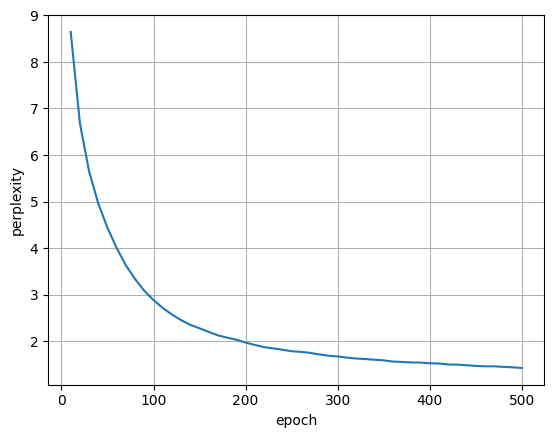

In [9]:
import torch

# 设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 超参数
vocab_size, num_hiddens = len(vocab), 256
num_epochs, lr = 500, 1

# 模型
model = RNNModelScratch(
    vocab_size,
    num_hiddens,
    device,
    get_lstm_params,
    init_lstm_state,
    lstm
)

# 训练
train_ch8(model, train_iter, vocab, lr, num_epochs, device)